# Structure of the PSF HDF5 file

The input file containing the Point Spread Function (PSF) of the PLATO telescope is also provided as an HDF5 file. The PLATO Simulator software knows about the structure and how to select the correct PSF from the file.

The PSF HDF5 file contains currently only one group named **T6000** which represents the temperature (K) of the star for which the PSF is modelled. This group contains 15 children (also groups) that represent the PSF at a certains radial (gnomonic) distance from the optical axis of the telescope. These groups are called '`arxxxxx`' where `xxxxx` is the radial distance [deg] multiplied by 1000. So, the PSF of a star at radial distance 7.053 deg from the optical axis is located in the group `ar07053`.

Each group `arxxxxx` contains in turn 4 children (datasets) named `az0`, `az90`, `az180`, `az270`. These groups contain the PSFs for azimuth 0, 90, 180, and 270. These datasets each contain a number of attributes that completely define the PSF.


TODO: insert picture here of the tree structure of the PSF file.

In [1]:
%matplotlib inline
%run setupMatplotlib.py

In [2]:
import os, sys

projectHome = "/Users/rik/Git/PlatoSim3"
os.environ['PLATO_PROJECT_HOME'] = projectHome

In [3]:
import numpy as np
import tables

In [4]:
psfFile = tables.open_file(projectHome + "/inputfiles/psf.hdf5")

In [5]:
psfFile.root.T6000

/T6000 (Group) ''
  children := ['ar18081' (Group), 'ar08454' (Group), 'ar14001' (Group), 'ar04238' (Group), 'ar02827' (Group), 'ar12625' (Group), 'ar09850' (Group), 'ar15370' (Group), 'ar16730' (Group), 'ar05647' (Group), 'ar01414' (Group), 'ar00000' (Group), 'ar07053' (Group), 'ar11241' (Group), 'ar18887' (Group)]

In [6]:
psfFile.root.T6000.ar00000

/T6000/ar00000 (Group) ''
  children := ['az270' (Array), 'az90' (Array), 'az180' (Array), 'az0' (Array)]

In [7]:
psfFile.root.T6000.ar00000.az180._v_attrs

/T6000/ar00000/az180._v_attrs (AttributeSet), 9 attributes:
   [Xdeg := 0.0,
    Xfp := 0.0,
    Ydeg := 0.0,
    Yfp := 0.0,
    azimuth := 180,
    orientation := 45.0,
    radius := 0.0,
    temperature := 6000,
    vignetting := 0.0]

In [8]:
psfFile.root.T6000.ar00000.az180._v_attrs['temperature']

6000

In [9]:
psf = np.array(psfFile.root.T6000.ar16730.az180)

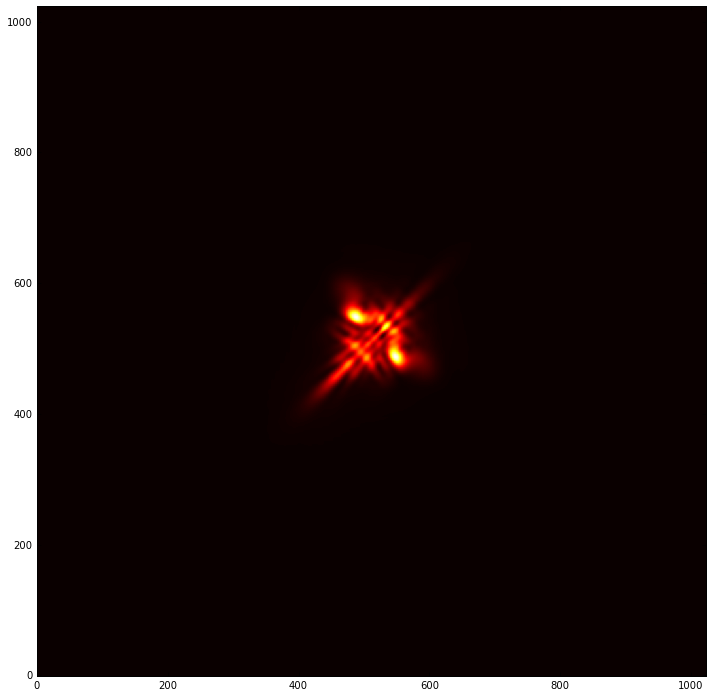

In [10]:
plt.imshow(psf, origin='lower', cmap=cm.hot, interpolation="nearest")